In [133]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [134]:
df1=pd.read_csv('fear_greed_index.csv')
df2=pd.read_csv('historical_data.csv')

# Data Preparation

In [135]:
print("Number of rows and columns of fear and greed table is : ",df1.shape)
print("Number of rows and columns of historical table is : ",df2.shape)

Number of rows and columns of fear and greed table is :  (2644, 4)
Number of rows and columns of historical table is :  (211224, 16)


### Missing values in Fear_Greed and historical data

In [136]:
print("Missing values in our first data set : \n ",df1.isna().sum())
print("\n")
print("Missing values in our second data set : \n ",df2.isna().sum())

Missing values in our first data set : 
  timestamp         0
value             0
classification    0
date              0
dtype: int64


Missing values in our second data set : 
  Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


### Converting timestamp and making both dates from both tables in the same format 

In [137]:
df1.rename(columns={'date':'Date'},inplace=True)
df1['Date']=pd.to_datetime(df1['Date'])

In [138]:
df1['timestamp']

0       1517463000
1       1517549400
2       1517635800
3       1517722200
4       1517808600
           ...    
2639    1745818200
2640    1745904600
2641    1745991000
2642    1746077400
2643    1746163800
Name: timestamp, Length: 2644, dtype: int64

In [139]:
df2['Timestamp IST']=pd.to_datetime(df2['Timestamp IST'],format='%d-%m-%Y %H:%M')
df2['Date']=df2['Timestamp IST'].dt.floor('D')

In [140]:
merged_data=pd.merge(df1,df2,on='Date',how='inner')

In [141]:
merged_data.head()

,timestamp,value,classification,Date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,1682919000,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0967,183.53,BUY,2023-05-01 01:06:00,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12
1,1682919000,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0824,156.39,BUY,2023-05-01 01:06:00,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12
2,1682919000,63,Greed,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.0722,137.08,BUY,2023-05-01 01:06:00,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12
3,1701754200,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.4933,1100.11,BUY,2023-12-05 03:11:00,0.0000,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.275027,6.320000e+14,1.700000e+12
4,1701754200,75,Extreme Greed,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.8681,1935.95,BUY,2023-12-05 03:11:00,0.4933,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.483987,2.340000e+14,1.700000e+12


### KPI Building

In [142]:
daily_pnl=merged_data.groupby(['Date','Account'])['Closed PnL'].sum().reset_index()
avg_daily_pnl_per_account=daily_pnl.groupby('Date')['Closed PnL'].sum().mean()
print("Average daily pnl per account is : ",round(avg_daily_pnl_per_account,3))

Average daily pnl per account is :  21408.115


In [143]:
win_rate=(merged_data['Closed PnL']>0).mean()*100
print("Win rate is : ",round(win_rate,3))

Win rate is :  41.125


In [144]:
avg_trade_size=merged_data['Size Tokens'].mean()
print("Average trade size : ",round(avg_trade_size,3))

Average trade size :  4623.341


In [145]:
average_trades_per_day=merged_data.groupby('Date').size().mean()
print("Average trades per day : ",round(average_trades_per_day,3))

Average trades per day :  440.956


In [146]:
merged_data['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36007
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Settlement                       1
Liquidated Isolated Short        1
Name: count, dtype: int64

In [147]:
long = ((merged_data['Direction'] == 'Open Long') | (merged_data['Direction'] == 'Close Long')).sum()
short = ((merged_data['Direction'] == 'Open Short') | (merged_data['Direction'] == 'Close Short')).sum()
ratio=long/short
print("Long/short : ",round(ratio,3))

Long/short :  1.301


# Part B — Analysis

C:\Users\Hamza\AppData\Local\Temp\ipykernel_25504\30869912.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comparison = data.groupby('classification').apply(compute_metrics)


Performance Comparison:

                  Avg PnL  Win Rate (%)      Drawdown
classification                                       
Fear            54.290400     42.076750  -35681.74723
Greed           42.743559     38.482794 -117990.10410


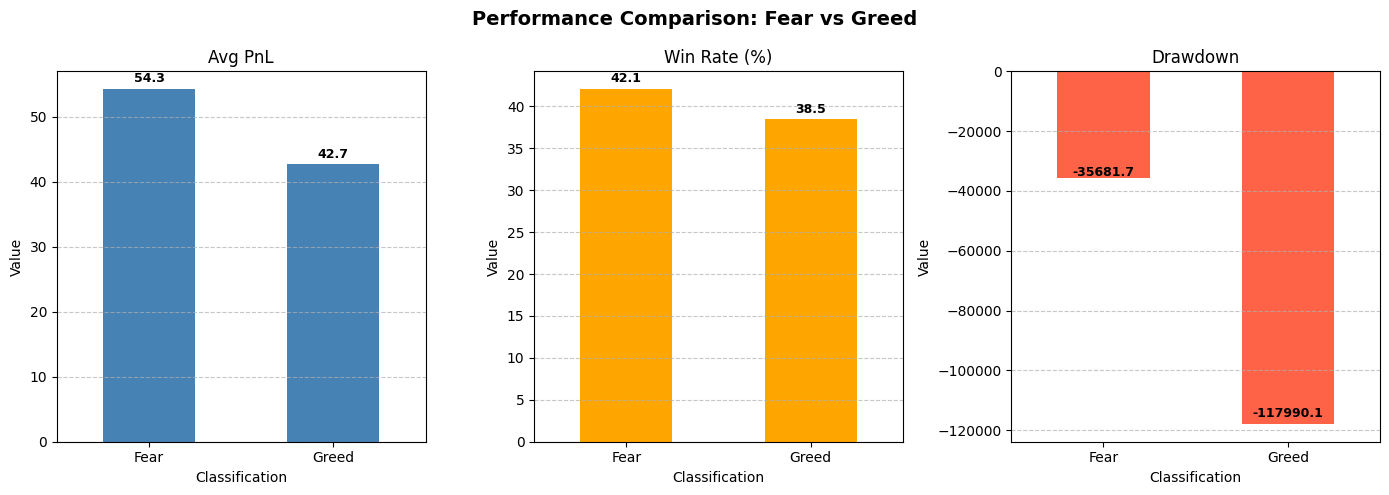

In [148]:
import matplotlib.pyplot as plt
merged_data['classification'] = merged_data['classification'].str.capitalize()
data = merged_data[merged_data['classification'].isin(['Fear', 'Greed'])]

def compute_metrics(df):
    avg_pnl = df['Closed PnL'].mean()
    win_rate = (df['Closed PnL'] > 0).mean() * 100
    drawdown = df['Closed PnL'].min()
    return pd.Series({
        'Avg PnL': avg_pnl,
        'Win Rate (%)': win_rate,
        'Drawdown': drawdown
    })

comparison = data.groupby('classification').apply(compute_metrics)
print("Performance Comparison:\n")
print(comparison)

metrics = ['Avg PnL', 'Win Rate (%)', 'Drawdown']
colors = ['steelblue', 'orange', 'tomato']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, color in zip(axes, metrics, colors):
    comparison[metric].plot(kind='bar', ax=ax, color=color, width=0.5)
    ax.set_title(metric)
    ax.set_xlabel('Classification')
    ax.set_ylabel('Value')
    ax.set_xticklabels(comparison.index, rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(comparison[metric]):
        ax.text(i, v + (abs(v) * 0.02), f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Performance Comparison: Fear vs Greed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###### Trading performance deteriorates during Greed periods, with a lower win rate (≈3.6 percentage points drop) and reduced average PnL (≈21% decline). Additionally,drawdowns are significantly larger during Greed, indicating higher risk exposure and more severe losse

Frequent vs Infrequent Traders:
Frequent      16
Infrequent    16 

Consistent vs Inconsistent Traders:
Closed PnL
Inconsistent         16
Consistent Winner    16 



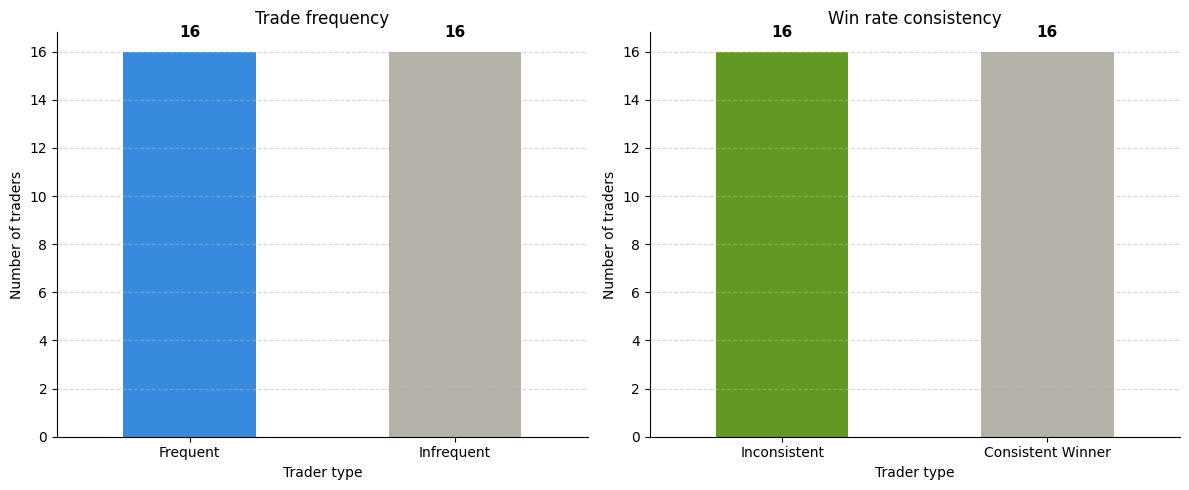

In [149]:
import matplotlib.pyplot as plt

def add_value_labels(ax):
    """Add count labels on top of each bar."""
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            int(bar.get_height()),
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

trades_per_trader = merged_data.groupby('Account').size()
threshold_freq    = trades_per_trader.median()

trader_type  = trades_per_trader.apply(
    lambda x: 'Frequent' if x > threshold_freq else 'Infrequent'
)
freq_counts  = trader_type.value_counts()

win_rate  = merged_data.groupby('Account')['Closed PnL'].apply(
    lambda x: (x > 0).mean()
)
threshold_win = win_rate.median()

trader_consistency = win_rate.apply(
    lambda x: 'Consistent Winner' if x > threshold_win else 'Inconsistent'
)
consistency_counts  = trader_consistency.value_counts()

print("Frequent vs Infrequent Traders:")
print(freq_counts.to_string(), "\n")

print("Consistent vs Inconsistent Traders:")
print(consistency_counts.to_string(), "\n")

g, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Trader Classification Overview", fontsize=14, fontweight='bold', y=1.02)

# Chart 1 – frequency
freq_counts.plot(kind='bar', ax=ax1, color=['#378ADD', '#B4B2A9'],
                 width=0.5, edgecolor='none')
ax1.set_title("Trade frequency", fontsize=12)
ax1.set_xlabel("Trader type")
ax1.set_ylabel("Number of traders")
ax1.set_xticklabels(freq_counts.index, rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.spines[['top', 'right']].set_visible(False)
add_value_labels(ax1)

# Chart 2 – consistency
consistency_counts.plot(kind='bar', ax=ax2, color=['#639922', '#B4B2A9'],
                        width=0.5, edgecolor='none')
ax2.set_title("Win rate consistency", fontsize=12)
ax2.set_xlabel("Trader type")
ax2.set_ylabel("Number of traders")
ax2.set_xticklabels(consistency_counts.index, rotation=0)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.spines[['top', 'right']].set_visible(False)
add_value_labels(ax2)

plt.tight_layout()
plt.show()

# Insights

Cost of Trading by Token Size:

            Avg_Fee  Avg_Gross_PnL  Avg_Net_PnL  Avg_Cost_Pct  Total_Trades  Win_Rate
Token Bin                                                                            
Small          2.05          14.20        12.15          0.02         52813     38.38
Medium         0.99          23.15        22.16          0.02         52954     40.01
Large          0.48          46.95        46.48          0.02         52647     42.64
Very Large     1.14         109.97       108.83          0.08         52804     43.04


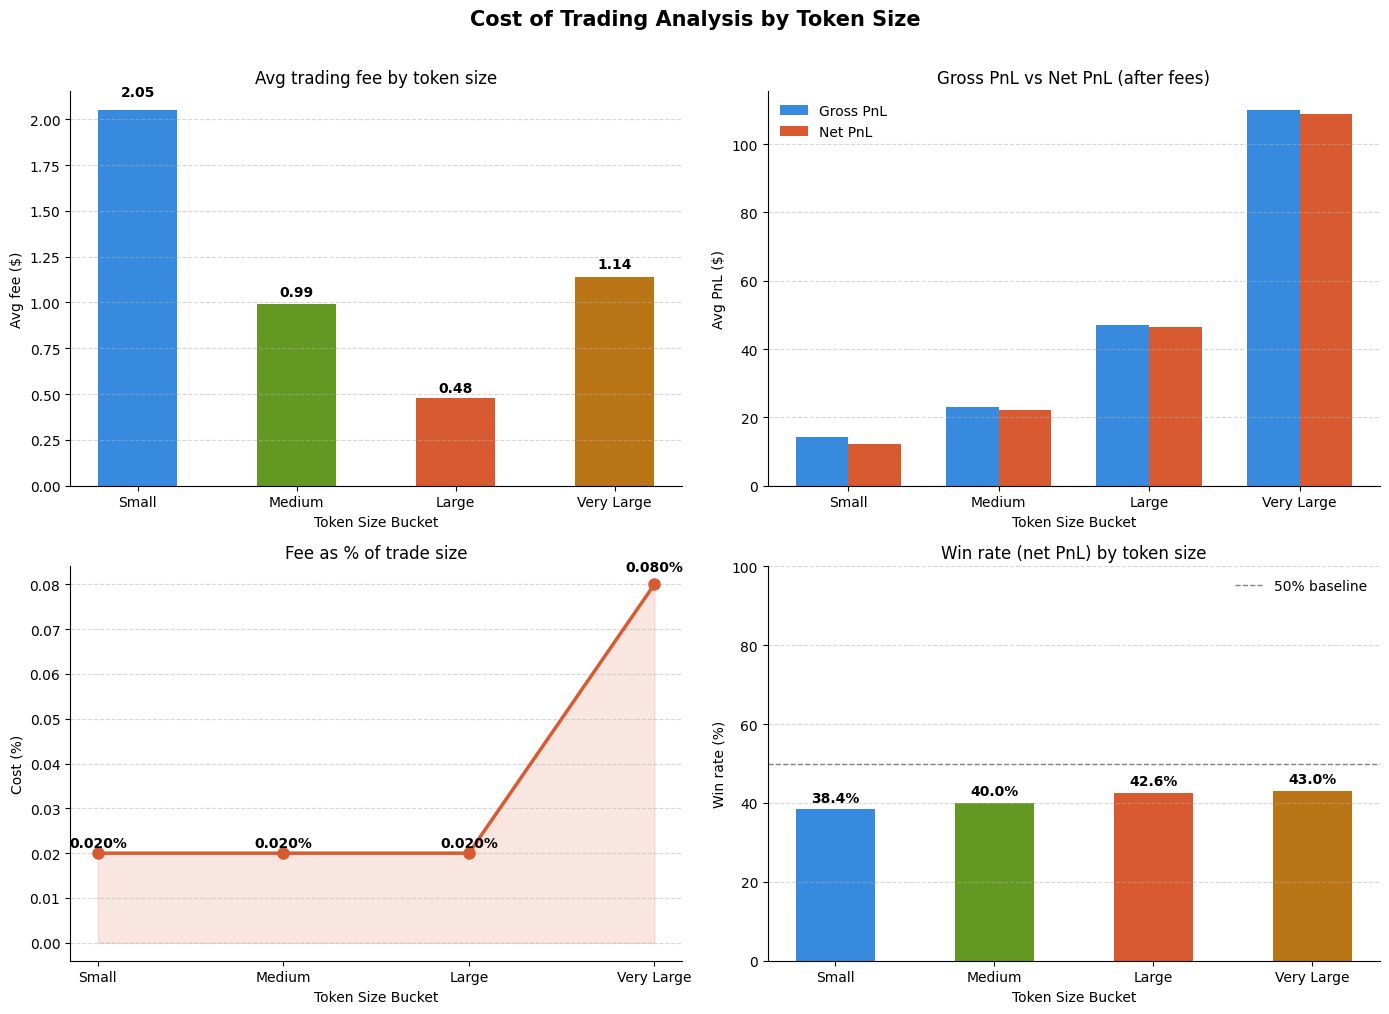

In [150]:
df = merged_data.copy()

df['Trade Cost']     = df['Fee']                          
df['Net PnL']        = df['Closed PnL'] - df['Trade Cost']
df['Cost %']         = (df['Trade Cost'] / df['Size USD'].abs()) * 100  
df['Cost Efficiency']= df['Closed PnL'] / df['Size USD'].abs()          


df['Token Bin'] = pd.qcut(df['Size Tokens'], q=4, labels=['Small', 'Medium', 'Large', 'Very Large'])


cost_analysis = df.groupby('Token Bin', observed=True).agg(
    Avg_Fee         = ('Trade Cost', 'mean'),
    Avg_Gross_PnL   = ('Closed PnL', 'mean'),
    Avg_Net_PnL     = ('Net PnL',    'mean'),
    Avg_Cost_Pct    = ('Cost %',     'mean'),
    Total_Trades    = ('Trade Cost', 'count'),
    Win_Rate        = ('Net PnL',    lambda x: (x > 0).mean() * 100)
).round(2)

print("Cost of Trading by Token Size:\n")
print(cost_analysis.to_string())


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Cost of Trading Analysis by Token Size", fontsize=15, fontweight='bold', y=1.01)

colors    = ['#378ADD', '#639922', '#D85A30', '#BA7517']
bins      = cost_analysis.index.tolist()

def style_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel("Token Size Bucket", fontsize=10)
    ax.set_xticks(range(len(bins)))
    ax.set_xticklabels(bins, rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

def add_labels(ax, values, fmt='{:.2f}'):
    for i, v in enumerate(values):
        offset = abs(v) * 0.03 if v != 0 else 0.5
        va     = 'bottom' if v >= 0 else 'top'
        sign   = -offset if v < 0 else offset
        ax.text(i, v + sign, fmt.format(v), ha='center', va=va, fontsize=10, fontweight='bold')

x = range(len(bins))

# Chart 1 — Avg Fee per token bucket
ax1 = axes[0, 0]
bars = ax1.bar(x, cost_analysis['Avg_Fee'], color=colors, width=0.5, edgecolor='none')
style_ax(ax1, "Avg trading fee by token size", "Avg fee ($)")
add_labels(ax1, cost_analysis['Avg_Fee'])

# Chart 2 — Gross vs Net PnL comparison
ax2 = axes[0, 1]
w   = 0.35
ax2.bar([i - w/2 for i in x], cost_analysis['Avg_Gross_PnL'], width=w,
        label='Gross PnL', color='#378ADD', edgecolor='none')
ax2.bar([i + w/2 for i in x], cost_analysis['Avg_Net_PnL'],   width=w,
        label='Net PnL',   color='#D85A30', edgecolor='none')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--')
style_ax(ax2, "Gross PnL vs Net PnL (after fees)", "Avg PnL ($)")
ax2.legend(fontsize=10, frameon=False)

# Chart 3 — Cost as % of trade size
ax3 = axes[1, 0]
ax3.plot(bins, cost_analysis['Avg_Cost_Pct'], marker='o', linewidth=2.5,
         color='#D85A30', markersize=8)
ax3.fill_between(range(len(bins)), cost_analysis['Avg_Cost_Pct'],
                 alpha=0.15, color='#D85A30')
style_ax(ax3, "Fee as % of trade size", "Cost (%)")
add_labels(ax3, cost_analysis['Avg_Cost_Pct'], fmt='{:.3f}%')

# Chart 4 — Win rate after fees
ax4 = axes[1, 1]
bars4 = ax4.bar(x, cost_analysis['Win_Rate'], color=colors, width=0.5, edgecolor='none')
ax4.axhline(50, color='gray', linewidth=1, linestyle='--', label='50% baseline')
style_ax(ax4, "Win rate (net PnL) by token size", "Win rate (%)")
ax4.set_ylim(0, 100)
ax4.legend(fontsize=10, frameon=False)
add_labels(ax4, cost_analysis['Win_Rate'], fmt='{:.1f}%')

plt.tight_layout()
plt.show()

##### Chart 1 FINDING: Small trades `$2.05 avg` are significantly more expensive than Large trades ($0.48).
##### TAKEAWAY: Trading small amounts results in a high "flat fee" penalty.

##### Chart 2 FINDING: Profit before fees (Blue) vs. after fees (Orange) shows a minimal gap.
##### EXAMPLE: `$109` Gross vs $108 Net for large trades.
##### TAKEAWAY: Fees have a negligible impact on absolute profit margins.

##### Chart 3 FINDING: Fees remain flat at 0.02% for most sizes but jump 4x to 0.08% for 'Very Large' trades.
##### TAKEAWAY: Large-scale liquidity/slippage creates a hidden cost spike for whales.

##### Chart 4 FINDING: Win rates improve with size (38% -> 43%) but stay below the 50% baseline.
##### TAKEAWAY: Higher conviction (larger) trades perform better, but the house still wins overall.

## ACTIONS

### 1.
### data shows Large trades have the best fee efficiency ($0.48 avg fee) and a reasonable win rate (42.6%). # ### Small trades cost 4x more in fees for worse outcomes. The recommendation is that we can set a minimum trade size policy to avoid the Small bucket entirely.

### 2.
### Very large trades jump to 0.08% cost vs 0.02% for every other bucket ,that's a 4x cost spike. Before scaling up trade sizes, the board needs to understand why is it exchange slippage, tiered fee structure, or liquidity issues? This needs a root cause analysis before any capital deployment decision.